In [1]:
!pip install pandas numpy spacy textstat matplotlib seaborn scipy -q
!python -m spacy download en_core_web_sm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 45.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 94.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import pandas as pd
import numpy as np
import spacy
import textstat
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
from scipy import stats
from scipy.stats import f_oneway
import warnings
import os
import random
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Load SpaCy
nlp = spacy.load('en_core_web_sm')

print("✓ Libraries loaded")

✓ Libraries loaded


In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

# PROJECT_PATH = '/content/drive/MyDrive/Precog_NLP_Task_FIXED'
# RESULTS_PATH = os.path.join(PROJECT_PATH, 'task1_results')
# os.makedirs(RESULTS_PATH, exist_ok=True)

# print(f"✓ Project path: {PROJECT_PATH}")
# print(f"✓ Results path: {RESULTS_PATH}")

## 1. Load Data

In [5]:
# Load datasets
class1_df = pd.read_csv('class1_human.csv')
class2_df = pd.read_csv('class2_ai_neutral.csv')
class3_df = pd.read_csv('class3_ai_mimicked.csv')

# Combine
df_combined = pd.concat([class1_df, class2_df, class3_df], ignore_index=True)

print("="*80)
print("DATASET LOADED")
print("="*80)
print(f"Class 1 (Human):      {len(class1_df):4d} samples")
print(f"Class 2 (AI Neutral): {len(class2_df):4d} samples")
print(f"Class 3 (AI Mimicked):{len(class3_df):4d} samples")
print(f"Total:                {len(df_combined):4d} samples")
print("="*80)

print("\nAuthor distribution:")
print(df_combined['author'].value_counts())

print("\nTopic distribution:")
print(df_combined['topic'].value_counts())

DATASET LOADED
Class 1 (Human):      1926 samples
Class 2 (AI Neutral):  500 samples
Class 3 (AI Mimicked): 500 samples
Total:                2926 samples

Author distribution:
author
Austen              1160
Dickens              766
AI                   500
Austen_mimicked      250
Dickens_mimicked     250
Name: count, dtype: int64

Topic distribution:
topic
original_literature         1926
Moral Corruption             200
Social Expectations          100
Self-Deception               100
Romantic Disillusionment     100
Social Class                 100
Familial Duty                100
Social Inequality            100
Social Stratification        100
Lost Innocence               100
Name: count, dtype: int64


## 2. Text Preprocessing

**CRITICAL**: Clean text properly before calculating lexical metrics.

In [6]:
def clean_text_for_analysis(text):
    """
    Clean text for lexical analysis.
    Removes punctuation to avoid token artifacts.
    """
    # Lowercase
    text = text.lower()

    # Remove ALL punctuation (critical for accurate word counts)
    text = re.sub(r'[^\w\s]', ' ', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply cleaning
df_combined['text_clean'] = df_combined['text'].apply(clean_text_for_analysis)

print("Text cleaning verification:")
print("\nOriginal:")
print(df_combined.iloc[0]['text'][:200])
print("\nCleaned:")
print(df_combined.iloc[0]['text_clean'][:200])
print("\n✓ Preprocessing complete")

Text cleaning verification:

Original:
Why was it so much worse that Harriet should be in love with Mr. Knightley, than with Frank Churchill? Why was the evil so dreadfully increased by Harriet's having some hope of a return? It darted thr

Cleaned:
why was it so much worse that harriet should be in love with mr knightley than with frank churchill why was the evil so dreadfully increased by harriet s having some hope of a return it darted through

✓ Preprocessing complete


## 3. Lexical Richness Analysis

### 3.1 Standardised Type-Token Ratio (TTR)

In [7]:
def compute_sttr(text, chunk_size=100):
    """
    Segmented Type-Token Ratio (STTR).
    Splits text into equal token chunks and averages TTR.
    """

    tokens = re.findall(r"\b\w+\b", text.lower())

    if len(tokens) < chunk_size:
        return np.nan  # avoid misleading high TTR

    chunks = [
        tokens[i:i+chunk_size]
        for i in range(0, len(tokens), chunk_size)
        if len(tokens[i:i+chunk_size]) == chunk_size
    ]

    ttrs = [len(set(chunk)) / len(chunk) for chunk in chunks]

    return np.mean(ttrs) if ttrs else np.nan

# Calculate STTR for all samples
df_combined['sttr'] = df_combined['text_clean'].apply(compute_sttr)

print("Standardised Type-Token Ratio by Class:")
print(df_combined.groupby('class')['sttr'].describe())

# Statistical test
human_sttr = df_combined[df_combined['class'] == 'human']['sttr']
ai_neutral_sttr = df_combined[df_combined['class'] == 'ai_neutral']['sttr']
ai_mimicked_sttr = df_combined[df_combined['class'] == 'ai_mimicked']['sttr']

f_stat, p_value = f_oneway(human_sttr, ai_neutral_sttr, ai_mimicked_sttr)
print(f"\nANOVA: F={f_stat:.4f}, p={p_value:.4e}")

if p_value < 0.05:
    print("✓ STTR is significantly different across classes (p < 0.05)")
else:
    print("⚠ STTR is NOT significantly different across classes")

Standardised Type-Token Ratio by Class:
              count      mean       std   min   25%   50%   75%   max
class                                                                
ai_mimicked   500.0  0.753860  0.035976  0.65  0.73  0.75  0.78  0.87
ai_neutral    472.0  0.787754  0.041690  0.66  0.76  0.79  0.82  0.89
human        1926.0  0.712991  0.044425  0.51  0.69  0.72  0.74  0.85

ANOVA: F=nan, p=nan
⚠ STTR is NOT significantly different across classes


### 3.2 Hapax Legomena

Count words appearing only once in a 5000-word sample (per class).

In [8]:
def calculate_hapax_per_class(class_df, sample_size=5000, tries=100):
    """
    Calculate Hapax Legomena for a class.
    Pool all text, take first 5000 words, count words appearing once.
    """
    # Pool all clean text
    all_text = ' '.join(class_df['text_clean'].tolist())
    words = all_text.split()
    hapax_count = 0

    for _ in range(tries):
      # Take first 5000 words
      i = random.randint(0, len(words) - sample_size)
      sample_words = words[i:sample_size+i]

      # Count frequencies
      word_counts = Counter(sample_words)

      # Count hapax (words appearing once)
      hapax_count += sum(1 for count in word_counts.values() if count == 1)

    return hapax_count/tries

# Calculate for each class
hapax_results = {}
for class_name in ['human', 'ai_neutral', 'ai_mimicked']:
    class_data = df_combined[df_combined['class'] == class_name]
    hapax = calculate_hapax_per_class(class_data)
    hapax_results[class_name] = hapax

print("Hapax Legomena (words appearing once in 5000-word sample):")
for class_name, count in hapax_results.items():
    print(f"  {class_name:15s}: {count:.2f} unique words")

print("\nInterpretation:")
print("  Higher hapax → More vocabulary diversity")

Hapax Legomena (words appearing once in 5000-word sample):
  human          : 959.19 unique words
  ai_neutral     : 725.25 unique words
  ai_mimicked    : 904.65 unique words

Interpretation:
  Higher hapax → More vocabulary diversity


## 4. Syntactic Complexity Analysis

In [9]:
def analyze_syntax(text):
    """
    Analyze syntactic complexity using spaCy.
    Returns:
    - avg_tree_depth: Average dependency tree depth
    - adj_noun_ratio: Ratio of adjectives to nouns
    """
    doc = nlp(text[:1000])  # Limit to 1000 chars for speed

    # Dependency tree depth
    def get_tree_depth(token):
        if not list(token.children):
            return 1
        return 1 + max(get_tree_depth(child) for child in token.children)

    tree_depths = [get_tree_depth(sent.root) for sent in doc.sents if sent]
    avg_tree_depth = np.mean(tree_depths) if tree_depths else 0

    # POS distribution
    pos_counts = Counter([token.pos_ for token in doc if not token.is_space])
    adj_count = pos_counts.get('ADJ', 0)
    noun_count = pos_counts.get('NOUN', 1)  # Avoid division by zero
    adj_noun_ratio = adj_count / noun_count

    return {
        'tree_depth': avg_tree_depth,
        'adj_noun_ratio': adj_noun_ratio
    }

print("Analyzing syntax (this may take a few minutes)...")

syntax_data = []
for idx, row in df_combined.iterrows():
    result = analyze_syntax(row['text'])
    syntax_data.append({
        'class': row['class'],
        'tree_depth': result['tree_depth'],
        'adj_noun_ratio': result['adj_noun_ratio']
    })

    if (idx + 1) % 100 == 0:
        print(f"  Processed {idx + 1}/{len(df_combined)}")

syntax_df = pd.DataFrame(syntax_data)

print("\nSyntactic Complexity by Class:")
print(syntax_df.groupby('class')[['tree_depth', 'adj_noun_ratio']].describe())

# Statistical tests
for metric in ['tree_depth', 'adj_noun_ratio']:
    human = syntax_df[syntax_df['class'] == 'human'][metric]
    ai_neutral = syntax_df[syntax_df['class'] == 'ai_neutral'][metric]
    ai_mimicked = syntax_df[syntax_df['class'] == 'ai_mimicked'][metric]

    f_stat, p_value = f_oneway(human, ai_neutral, ai_mimicked)
    print(f"\n{metric}: F={f_stat:.4f}, p={p_value:.4e}")

Analyzing syntax (this may take a few minutes)...
  Processed 100/2926
  Processed 200/2926
  Processed 300/2926
  Processed 400/2926
  Processed 500/2926
  Processed 600/2926
  Processed 700/2926
  Processed 800/2926
  Processed 900/2926
  Processed 1000/2926
  Processed 1100/2926
  Processed 1200/2926
  Processed 1300/2926
  Processed 1400/2926
  Processed 1500/2926
  Processed 1600/2926
  Processed 1700/2926
  Processed 1800/2926
  Processed 1900/2926
  Processed 2000/2926
  Processed 2100/2926
  Processed 2200/2926
  Processed 2300/2926
  Processed 2400/2926
  Processed 2500/2926
  Processed 2600/2926
  Processed 2700/2926
  Processed 2800/2926
  Processed 2900/2926

Syntactic Complexity by Class:
            tree_depth                                                    \
                 count      mean       std       min  25%  50%       75%   
class                                                                      
ai_mimicked      500.0  7.786029  1.097779  4.750000  7.0  7.

## 5. Punctuation Analysis

In [10]:
def analyze_punctuation(text):
    """
    Analyze punctuation density (per 100 words).
    """
    word_count = len(text.split())
    if word_count == 0:
        return {k: 0 for k in ['commas', 'semicolons', 'colons', 'exclamations', 'dashes']}

    return {
        'commas': (text.count(',') / word_count) * 100,
        'semicolons': (text.count(';') / word_count) * 100,
        'colons': (text.count(':') / word_count) * 100,
        'exclamations': (text.count('!') / word_count) * 100,
        'dashes': ((text.count('--') + text.count('—')) / word_count) * 100
    }

punct_data = []
for idx, row in df_combined.iterrows():
    result = analyze_punctuation(row['text'])
    result['class'] = row['class']
    punct_data.append(result)

punct_df = pd.DataFrame(punct_data)

print("Punctuation Density (per 100 words):")
print(punct_df.groupby('class')[['commas', 'semicolons', 'colons', 'exclamations', 'dashes']].mean())

Punctuation Density (per 100 words):
                commas  semicolons    colons  exclamations    dashes
class                                                               
ai_mimicked  10.856962    0.221648  0.039029      0.079697  0.000000
ai_neutral    7.712125    0.547426  0.100442      0.000000  0.003361
human         8.003241    1.352323  0.153639      0.132316  0.073719


## 6. Readability Metrics

In [11]:
def calculate_readability(text):
    """
    Calculate readability metrics.
    """
    return {
        'flesch_kincaid': textstat.flesch_kincaid_grade(text),
        'flesch_ease': textstat.flesch_reading_ease(text),
        'gunning_fog': textstat.gunning_fog(text),
        'avg_sentence_length': textstat.avg_sentence_length(text)
    }

read_data = []
for idx, row in df_combined.iterrows():
    result = calculate_readability(row['text'])
    result['class'] = row['class']
    read_data.append(result)

read_df = pd.DataFrame(read_data)

print("Readability Metrics by Class:")
print(read_df.groupby('class')[['flesch_kincaid', 'flesch_ease', 'gunning_fog', 'avg_sentence_length']].describe())

# Statistical test
for metric in ['flesch_kincaid', 'flesch_ease']:
    human = read_df[read_df['class'] == 'human'][metric]
    ai_neutral = read_df[read_df['class'] == 'ai_neutral'][metric]
    ai_mimicked = read_df[read_df['class'] == 'ai_mimicked'][metric]

    f_stat, p_value = f_oneway(human, ai_neutral, ai_mimicked)
    print(f"\n{metric}: F={f_stat:.4f}, p={p_value:.4e}")

Readability Metrics by Class:
            flesch_kincaid                                            \
                     count       mean       std       min        25%   
class                                                                  
ai_mimicked          500.0  14.800763  2.458730  8.428151  13.107895   
ai_neutral           500.0  16.228348  1.808405  8.780360  15.085184   
human               1926.0  14.095814  6.662033  3.206728   9.880375   

                                             flesch_ease             ...  \
                   50%        75%        max       count       mean  ...   
class                                                                ...   
ai_mimicked  14.515237  16.368190  23.341987       500.0  34.613116  ...   
ai_neutral   16.252055  17.451295  21.479282       500.0  13.892154  ...   
human        12.893811  16.488544  71.821117      1926.0  52.008122  ...   

            gunning_fog            avg_sentence_length                        \


## 7. Visualizations

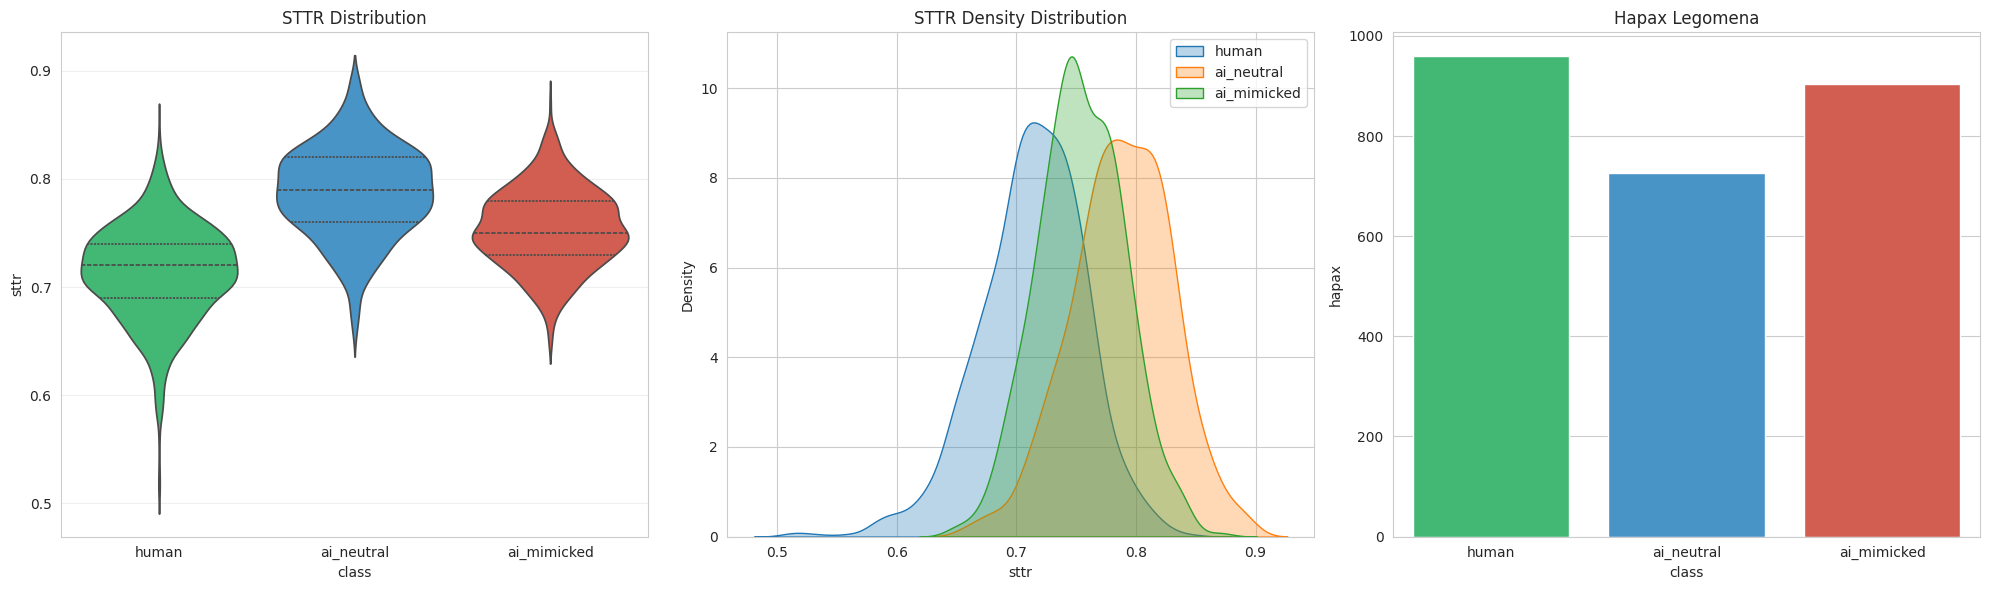

✓ Figure 1 saved


In [14]:
# ===== FIGURE 1: LEXICAL RICHNESS (Improved) =====
colors = {'human': '#2ecc71', 'ai_neutral': '#3498db', 'ai_mimicked': '#e74c3c'}
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Violin STTR ---
sns.violinplot(
    data=df_combined,
    x='class', y='sttr',
    order=['human', 'ai_neutral', 'ai_mimicked'],
    palette=colors,
    inner='quartile',
    ax=axes[0]
)
axes[0].set_title('STTR Distribution')
axes[0].grid(axis='y', alpha=0.3)

# --- KDE Distribution ---
for cls in ['human', 'ai_neutral', 'ai_mimicked']:
    sns.kdeplot(
        df_combined[df_combined['class'] == cls]['sttr'].dropna(),
        label=cls,
        fill=True,
        alpha=0.3,
        ax=axes[1]
    )
axes[1].set_title('STTR Density Distribution')
axes[1].legend()

# --- Hapax Barplot ---
hapax_df = pd.DataFrame(list(hapax_results.items()), columns=['class', 'hapax'])
sns.barplot(
    data=hapax_df,
    x='class', y='hapax',
    order=['human', 'ai_neutral', 'ai_mimicked'],
    palette=colors,
    ax=axes[2]
)
axes[2].set_title('Hapax Legomena')

plt.tight_layout()
plt.savefig('fig1_lexical_richness.png', dpi=300)
plt.show()

print("✓ Figure 1 saved")


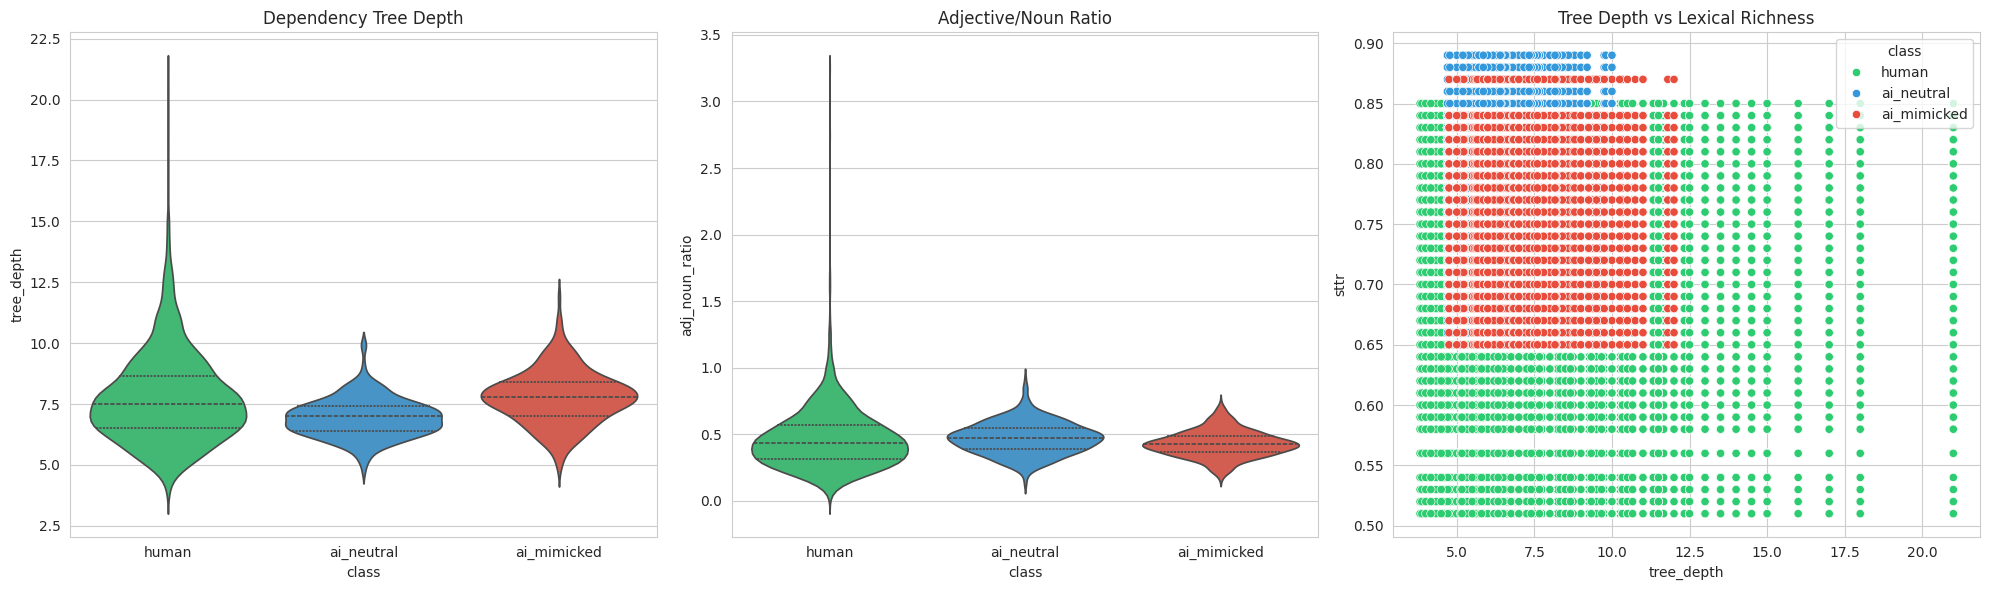

✓ Figure 2 saved


In [15]:
# ===== FIGURE 2: SYNTACTIC COMPLEXITY =====
colors = {'human': '#2ecc71', 'ai_neutral': '#3498db', 'ai_mimicked': '#e74c3c'}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Tree depth violin
sns.violinplot(
    data=syntax_df,
    x='class', y='tree_depth',
    order=['human', 'ai_neutral', 'ai_mimicked'],
    palette=colors,
    inner='quartile',
    ax=axes[0]
)
axes[0].set_title('Dependency Tree Depth')

# Adj/Noun violin
sns.violinplot(
    data=syntax_df,
    x='class', y='adj_noun_ratio',
    order=['human', 'ai_neutral', 'ai_mimicked'],
    palette=colors,
    inner='quartile',
    ax=axes[1]
)
axes[1].set_title('Adjective/Noun Ratio')

# Scatter relation
merged_syn = pd.merge(df_combined[['class','sttr']], syntax_df, on='class')

sns.scatterplot(
    data=merged_syn,
    x='tree_depth',
    y='sttr',
    hue='class',
    palette=colors,
    ax=axes[2]
)
axes[2].set_title('Tree Depth vs Lexical Richness')

plt.tight_layout()
plt.savefig('fig2_syntactic_complexity.png', dpi=300)
plt.show()

print("✓ Figure 2 saved")


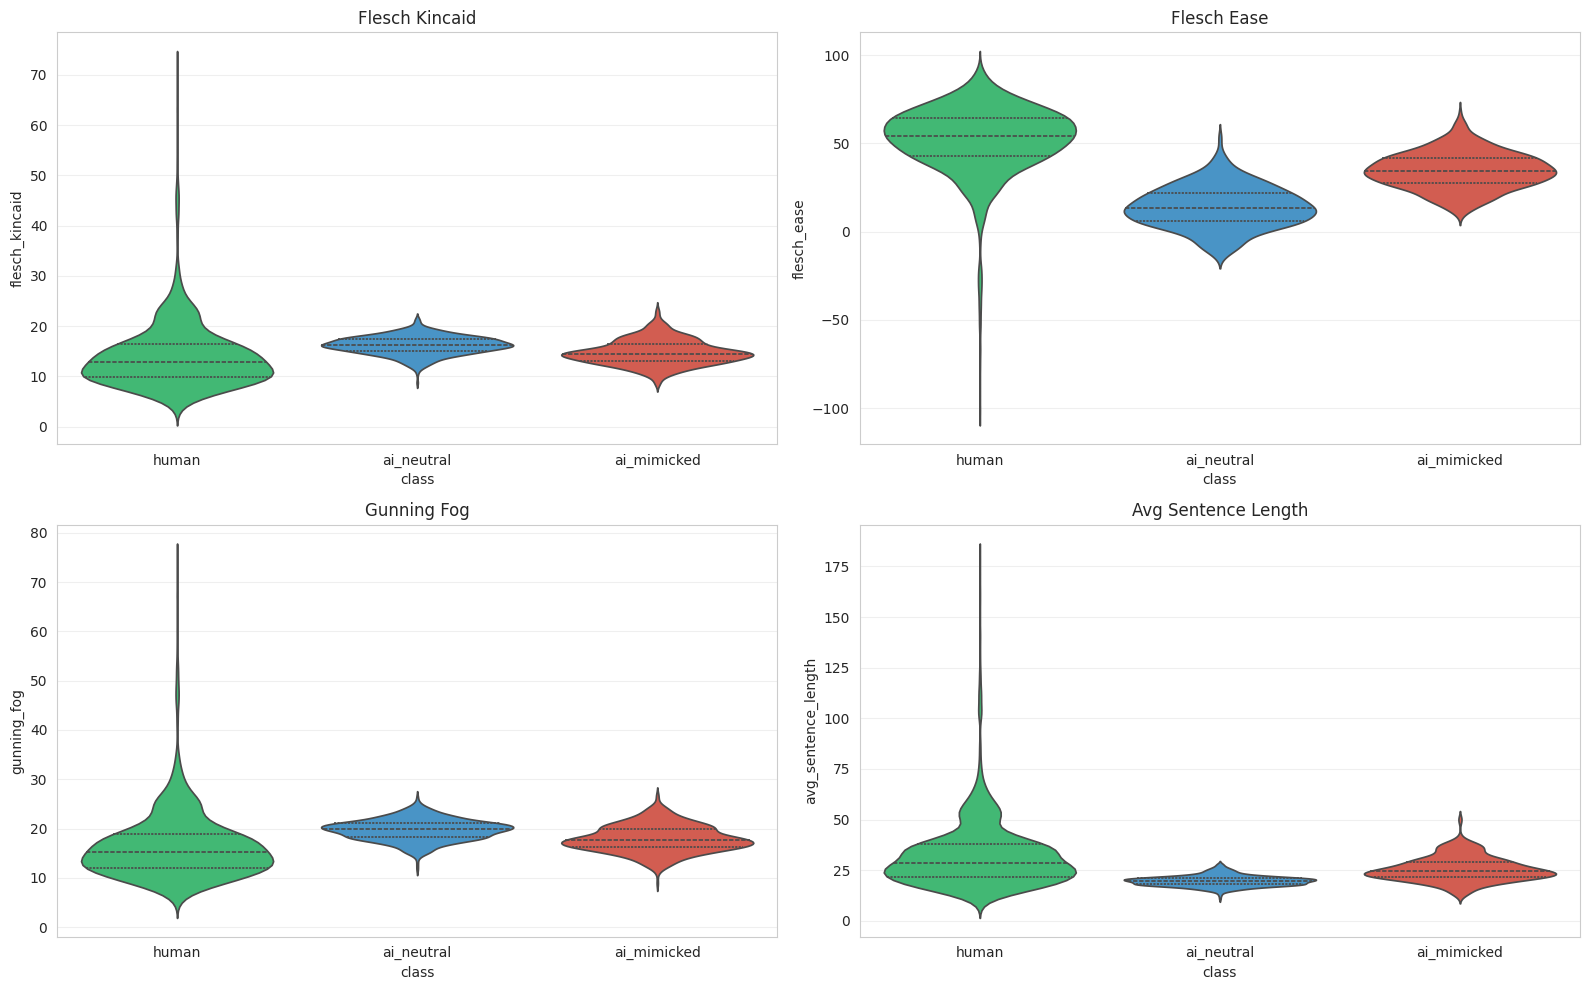

✓ Figure 3 saved


In [16]:
# ===== FIGURE 3: READABILITY =====

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

metrics = ['flesch_kincaid', 'flesch_ease', 'gunning_fog', 'avg_sentence_length']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]

    sns.violinplot(
        data=read_df,
        x='class', y=metric,
        order=['human', 'ai_neutral', 'ai_mimicked'],
        palette=colors,
        inner='quartile',
        ax=ax
    )

    ax.set_title(metric.replace('_',' ').title())
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig3_readability.png', dpi=300)
plt.show()

print("✓ Figure 3 saved")


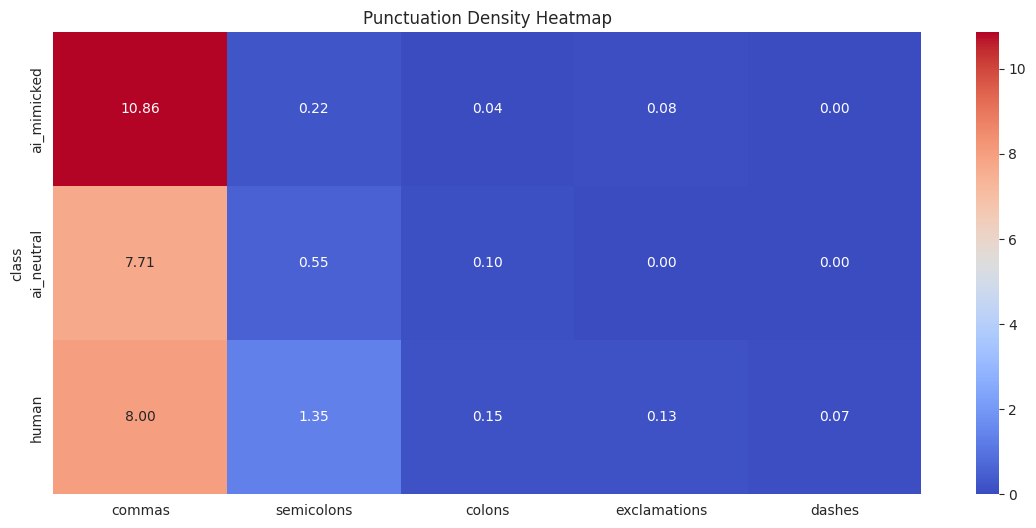

✓ Figure 4 saved


In [17]:
# ===== FIGURE 4: PUNCTUATION HEATMAP =====

punct_cols = [c for c in punct_df.columns if c != 'class']

heatmap_data = punct_df.groupby('class')[punct_cols].mean()

plt.figure(figsize=(14,6))
sns.heatmap(
    heatmap_data,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Punctuation Density Heatmap')
plt.savefig('fig4_punctuation_heatmap.png', dpi=300)
plt.show()

print("✓ Figure 4 saved")


## 8. Summary Report

In [18]:
# ===== SUMMARY TABLE =====

summary_data = []

for class_name in ['human','ai_neutral','ai_mimicked']:

    class_df_data = df_combined[df_combined['class']==class_name]
    class_read = read_df[read_df['class']==class_name]
    class_punct = punct_df[punct_df['class']==class_name]

    summary_data.append({
        'Class': class_name,
        'Samples': len(class_df_data),
        'STTR_mean': f"{class_df_data['sttr'].mean():.4f}",
        'STTR_std': f"{class_df_data['sttr'].std():.4f}",
        'Hapax': hapax_results[class_name],
        'FK_Grade': f"{class_read['flesch_kincaid'].mean():.2f}",
        'TreeDepth': f"{syntax_df[syntax_df['class']==class_name]['tree_depth'].mean():.2f}",
        'AdjToNounRatio' : f"{syntax_df[syntax_df['class']==class_name]['adj_noun_ratio'].mean():.2f}",
        'Semicolons': f"{class_punct['semicolons'].mean():.2f}",
        'Commas': f"{class_punct['commas'].mean():.2f}"
    })

summary_table = pd.DataFrame(summary_data)

print("="*100)
print(summary_table.to_string(index=False))
print("="*100)

summary_table.to_csv('task1_summary.csv',index=False)

print("✓ Summary saved")


      Class  Samples STTR_mean STTR_std  Hapax FK_Grade TreeDepth AdjToNounRatio Semicolons Commas
      human     1926    0.7130   0.0444 959.19    14.10      7.76           0.46       1.35   8.00
 ai_neutral      500    0.7878   0.0417 725.25    16.23      6.94           0.47       0.55   7.71
ai_mimicked      500    0.7539   0.0360 904.65    14.80      7.79           0.43       0.22  10.86
✓ Summary saved


In [20]:
print("Generating consolidated row-wise metrics using existing functions...")

# 1. Define Row-Wise Wrappers
# ---------------------------
def get_row_hapax(text_clean):
    """Calculates hapax count for a single row (reuses logic from class-level approach)."""
    words = text_clean.split()
    if not words: return 0
    counts = Counter(words)
    return sum(1 for word, count in counts.items() if count == 1)

def get_syntax_metrics(text):
    """Calculates syntax metrics on ORIGINAL text (needs punctuation/structure)."""
    doc = nlp(text)

    # Tree Depth (Average max depth per sentence)
    sent_depths = []
    for sent in doc.sents:
        roots = [token for token in sent if token.head == token]
        if not roots: continue
        def _get_depth(node):
            if not list(node.children): return 1
            return 1 + max((_get_depth(child) for child in node.children), default=0)
        sent_depths.append(_get_depth(roots[0]))

    avg_depth = np.mean(sent_depths) if sent_depths else 0

    # Adj to Noun Ratio
    adjs = len([t for t in doc if t.pos_ == 'ADJ'])
    nouns = len([t for t in doc if t.pos_ == 'NOUN'])
    adj_noun_ratio = adjs / nouns if nouns > 0 else 0

    return avg_depth, adj_noun_ratio

# 2. Apply Calculations
# ---------------------
# TTR is likely already in df_combined['ttr'] from your previous cells.
# If not, uncomment the next line:
df_combined['STTR_mean'] = df_combined['text_clean'].apply(compute_sttr)

# Hapax (Row-wise)
df_combined['hapax'] = df_combined['text_clean'].apply(get_row_hapax)

# Syntax (TreeDepth & AdjToNoun)
# We apply this to 'text' (original), NOT 'text_clean'
print("Processing syntax (this may take 30-60s)...")
syntax_results = df_combined['text'].apply(get_syntax_metrics)
df_combined['TreeDepth'] = syntax_results.apply(lambda x: x[0])
df_combined['AdjToNounRatio'] = syntax_results.apply(lambda x: x[1])

# Readability & Punctuation
df_combined['FK_Grade'] = df_combined['text'].apply(textstat.flesch_kincaid_grade)
df_combined['Semicolons'] = df_combined['text'].apply(lambda x: x.count(';'))
df_combined['Commas'] = df_combined['text'].apply(lambda x: x.count(','))

# 3. Export Consolidated CSV
# --------------------------
final_columns = [
    'text',             # The Sample
    'class',            # The Label
    'sttr',
    'hapax',
    'TreeDepth',
    'AdjToNounRatio',
    'FK_Grade',
    'Semicolons',
    'Commas'
]

# Create final dataframe and rename 'text' to 'sample' if desired
consolidated_df = df_combined[final_columns].copy()
consolidated_df.rename(columns={'text': 'sample'}, inplace=True)

output_filename = 'task1_results.csv'
consolidated_df.to_csv(output_filename, index=False)

print(f"\n✓ Saved consolidated metrics to: {output_filename}")
print(consolidated_df.head(3).to_string())

Generating consolidated row-wise metrics using existing functions...
Processing syntax (this may take 30-60s)...

✓ Saved consolidated metrics to: task1_results.csv
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 sample  class  sttr  hapax  TreeDepth  AdjToNounRatio   FK_Grade  Semicolons  Comm